In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import XLNetTokenizer, XLNetModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import cohen_kappa_score

from scipy.stats import pearsonr

from tqdm import tqdm


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16                  
EPOCHS = 10                      
PATIENCE = 3    
LEARNING_RATE = 2e-5
MAX_LENGTH = 512
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(DEVICE)

cuda


In [3]:
df = pd.read_csv(
    "task2_ielts_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)
print("Total essays:", len(df))
df.head(20)

Total essays: 9782


,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311
5,Some people believe that governments should pa...,Regarding the suggestions that governments sho...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,267
6,Some people believe that governments should pa...,Nowadays many people argue that univerties gra...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,265
7,Some people believe that governments should pa...,It is believed that governments ought to pay f...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,258
8,Some people believe that governments should pa...,"In recent years, in some countries, including ...",NaN,NaN,NaN,NaN,5.5,5.5,NaN,339
9,Some people believe that governments should pa...,Going to university is an important step in li...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,409


In [4]:
criteria_cols = ["Task_Response", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]

df_task2 = df.copy()

df_full = df_task2.dropna(subset=criteria_cols)
df_missing = df_task2[df_task2[criteria_cols].isna().any(axis=1)]

print("Full labeled:", len(df_full))
print("Missing:", len(df_missing))

Full labeled: 9120
Missing: 662


In [5]:
df[df["Task_Response"].isna()][
    ["Task_Response", "Coherence_Cohesion", 
     "Lexical_Resource", "Range_Accuracy"]
].isna().sum()

Task_Response         662
Coherence_Cohesion    662
Lexical_Resource      662
Range_Accuracy        662
dtype: int64

In [6]:
print("\nDESCRIBE FULL")
print(df_full[criteria_cols + ["Overall_Clean"]].describe())

print("\nDESCRIBE MISSING")
print(df_missing["Overall_Clean"].describe())

df_full["criteria_mean"] = df_full[criteria_cols].mean(axis=1)

print("\nCorrelation mean(criteria) vs Overall:")
print(pearsonr(df_full["criteria_mean"], df_full["Overall_Clean"]))

print("\nMAE consistency:")
print(mean_absolute_error(df_full["criteria_mean"], df_full["Overall_Clean"]))


DESCRIBE FULL
       Task_Response  Coherence_Cohesion  Lexical_Resource  Range_Accuracy  \
count    9120.000000         9120.000000       9120.000000     9120.000000   
mean        6.030482            5.893421          5.718147        5.636404   
std         1.489666            1.620728          1.486432        1.531134   
min         0.000000            0.000000          0.000000        0.000000   
25%         5.500000            5.000000          5.000000        5.000000   
50%         6.500000            6.000000          6.000000        6.000000   
75%         7.000000            7.000000          7.000000        6.500000   
max         9.000000            9.000000          9.000000        9.000000   

       Overall_Clean  
count    9120.000000  
mean        5.879221  
std         1.514604  
min         0.000000  
25%         5.000000  
50%         6.000000  
75%         7.000000  
max         9.000000  

DESCRIBE MISSING
count    662.000000
mean       6.741692
std        1.1095

In [7]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal < 0.75:   
        return integer + 0.5
    else:
        return integer + 1

In [8]:
df_full["input_text"] = (
    "Overall Score: " + df_full["Overall"].astype(str) +
    " | Word count: " + df_full["length"].astype(str) +
    " | Question: " + df_full["Question"].astype(str) +
    " [SEP] Essay: " + df_full["Essay"].astype(str)
)

In [9]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

encoded_inputs = tokenizer(
    df_full["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

input_ids = encoded_inputs["input_ids"]
attention_masks = encoded_inputs["attention_mask"]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
criteria = df_full[criteria_cols].values / 9.0
overall = df_full["Overall_Clean"].values / 9.0

criteria = torch.tensor(criteria, dtype=torch.float32)
overall = torch.tensor(overall, dtype=torch.float32)

In [11]:
indices = np.arange(len(df_full))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_SEED
)

print(len(train_idx), len(val_idx), len(test_idx))

7296 912 912


In [12]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_masks[train_idx],
    criteria[train_idx],
    overall[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_masks[val_idx],
    criteria[val_idx],
    overall[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_masks[test_idx],
    criteria[test_idx],
    overall[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [13]:
class XLNetMultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = XLNetModel.from_pretrained("xlnet-base-cased")

        self.dropout = nn.Dropout(0.3)

        hidden = self.encoder.config.hidden_size

        self.criteria_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

        self.overall_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        pooled = (hidden * attention_mask.unsqueeze(-1)).sum(dim=1) / \
                 attention_mask.sum(dim=1, keepdim=True)

        pooled = self.dropout(pooled)

        criteria = torch.sigmoid(self.criteria_head(pooled))
        overall = torch.sigmoid(self.overall_head(pooled)).squeeze(1)
        
        return criteria, overall



In [14]:
model = XLNetMultiHead().to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetModel LOAD REPORT from: xlnet-base-cased
Key            | Status     |  | 
---------------+------------+--+-
lm_loss.bias   | UNEXPECTED |  | 
lm_loss.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []


In [16]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [17]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for ids, masks, crit, overall in tqdm(train_loader):

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)
        crit = crit.to(DEVICE)
        overall = overall.to(DEVICE)

        optimizer.zero_grad()

        crit_pred, overall_pred = model(ids, masks)

        loss_criteria = criterion(crit_pred, crit)
        loss_overall = criterion(overall_pred, overall)

        loss_consistency = criterion(
            crit_pred.mean(dim=1),
            overall
        )

        loss = (
            0.5 * loss_criteria +
            0.3 * loss_overall +
            0.2 * loss_consistency
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for ids, masks, crit, overall in val_loader:

            ids = ids.to(DEVICE)
            masks = masks.to(DEVICE)
            overall = overall.to(DEVICE)

            _, overall_pred = model(ids, masks)

            loss = criterion(overall_pred, overall)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)


    
    logs.append({
        "epoch": epoch+1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "xlnetbase_task2_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break



Epoch 1/10


  0%|          | 0/456 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

100%|██████████| 456/456 [01:26<00:00,  5.28it/s]


Train Loss: 0.028737388690116637
Val Loss: 0.01600830549406901

Epoch 2/10


...

Train Loss: 0.00404170421135955
Val Loss: 0.004574813714594041

Epoch 7/10


100%|██████████| 456/456 [01:27<00:00,  5.23it/s]


Train Loss: 0.0036914920992945043
Val Loss: 0.004759941989425243

Epoch 8/10


100%|██████████| 456/456 [01:26<00:00,  5.25it/s]


Train Loss: 0.0033463105667084292
Val Loss: 0.004546027808254094
Early stopping


In [18]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv("training_logs_xlnet_task2.csv", index=False)

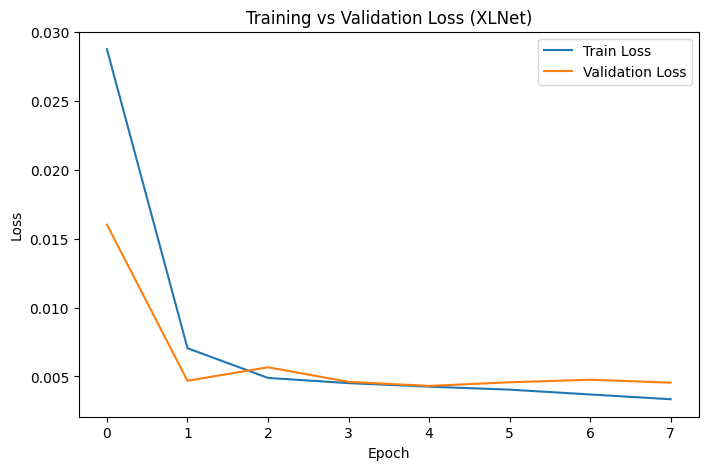

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (XLNet)")
plt.legend()

plt.show()

In [20]:
model.load_state_dict(torch.load("xlnetbase_task2_model.pt", map_location=DEVICE))
model.eval()

XLNetMultiHead(
  (encoder): XLNetModel(
    (word_embedding): Embedding(32000, 768)
    (layer): ModuleList(
      (0-11): 12 x XLNetLayer(
        (rel_attn): XLNetRelativeAttention(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ff): XLNetFeedForward(
          (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (layer_1): Linear(in_features=768, out_features=3072, bias=True)
          (layer_2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (activation_function): GELUActivation()
        )
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (criteria_head): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  

In [21]:
all_criteria = []
all_overall = []
all_true = []

with torch.no_grad():

    for ids, masks, crit, overall in test_loader:

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)

        crit_pred, overall_pred = model(ids, masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        all_criteria.append(crit_pred.cpu().numpy())
        all_overall.append(overall_pred.cpu().numpy())
        all_true.append(overall.cpu().numpy())

all_criteria = np.vstack(all_criteria) * 9
overall_pred = np.concatenate(all_overall) * 9
overall_true = np.concatenate(all_true) * 9

In [22]:
vectorized_round = np.vectorize(round_band, otypes=[float])


In [23]:
print(overall_pred[:20])
print(vectorized_round(overall_pred)[:20])

[6.917466  6.8376055 6.1581993 6.6988125 6.511246  3.5400667 7.531176
 5.992185  7.766465  3.2369123 3.4606926 3.521748  3.5942597 3.6258702
 7.2528    4.2223725 7.1172404 6.6228895 7.848735  6.16002  ]
[7.  7.  6.  6.5 6.5 3.5 7.5 6.  8.  3.  3.5 3.5 3.5 3.5 7.5 4.  7.  6.5
 8.  6. ]


In [24]:
mae = mean_absolute_error(overall_true, overall_pred)
rmse = np.sqrt(mean_squared_error(overall_true, overall_pred))
pearson = pearsonr(overall_true, overall_pred)[0]

within_half = np.mean(np.abs(overall_pred - overall_true) <= 0.5)

true_band = np.round(overall_true * 2).astype(int)
pred_band = np.round(overall_pred * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.3714892268180847
RMSE: 0.540708571793651
Pearson: 0.94037765
Within ±0.5: 0.7642543859649122
QWK: 0.9335999186856829


In [25]:
criteria_mean = all_criteria.mean(axis=1)

print("\n===== CONSISTENCY CHECK =====")
print("MAE(mean(criteria), overall_true):",
      mean_absolute_error(overall_true, criteria_mean))

print("Pearson:",
      pearsonr(criteria_mean, overall_true)[0])


===== CONSISTENCY CHECK =====
MAE(mean(criteria), overall_true): 0.3752424120903015
Pearson: 0.93956393


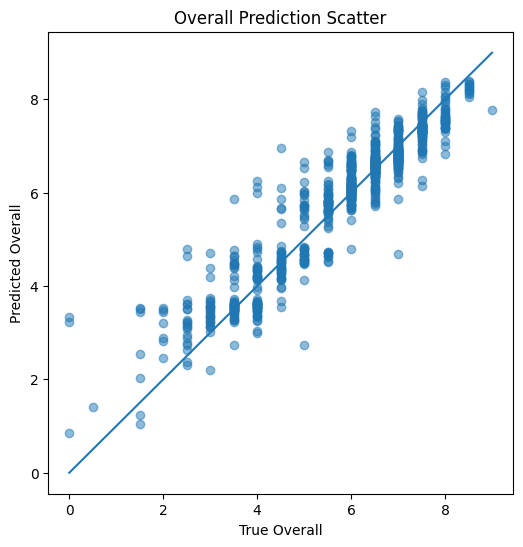

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(overall_true, overall_pred, alpha=0.5)

# đường y = x (perfect prediction)
plt.plot([0, 9], [0, 9])

plt.xlabel("True Overall")
plt.ylabel("Predicted Overall")
plt.title("Overall Prediction Scatter")

plt.show()

In [27]:
test_df = df_full.iloc[test_idx].copy().reset_index(drop=True)

overall_pred_rounded = vectorized_round(overall_pred)
criteria_rounded = vectorized_round(all_criteria)

test_df["overall_pred_raw"] = overall_pred
test_df["overall_pred"] = overall_pred_rounded

test_df["Task_Response_pred"] = all_criteria[:, 0]
test_df["Coherence_Cohesion_pred"] = all_criteria[:, 1]
test_df["Lexical_Resource_pred"] = all_criteria[:, 2]
test_df["Range_Accuracy_pred"] = all_criteria[:, 3]

test_df["Task_Response_pred_round"] = criteria_rounded[:, 0]
test_df["Coherence_Cohesion_pred_round"] = criteria_rounded[:, 1]
test_df["Lexical_Resource_pred_round"] = criteria_rounded[:, 2]
test_df["Range_Accuracy_pred_round"] = criteria_rounded[:, 3]

test_df["error_raw"] = test_df["overall_pred_raw"] - test_df["Overall"]
test_df["error_round"] = test_df["overall_pred"] - test_df["Overall"]

test_df["criteria_mean"] = all_criteria.mean(axis=1)
test_df["criteria_std"] = np.std(all_criteria, axis=1)

test_df.head(10)

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length,...,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Response_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,error_raw,error_round,criteria_std
0,The range of technology available to people is...,The increasing range of technology available t...,8.0,8.0,7.0,7.0,7.0,7.5,### Task Achievement:\n- The candidate has add...,263,...,7.030267,6.699297,6.600718,7.0,7.0,6.5,6.5,-0.082534,0.0,0.191928
1,Some people believe that what children watch o...,Televisions can certainly bring a change in a ...,7.0,7.0,6.5,6.5,7.0,7.0,## Task Achievement:\n- The candidate has addr...,298,...,7.002341,6.697944,6.623761,7.0,7.0,6.5,6.5,-0.162395,0.0,0.174327
2,Some people think that public health within a ...,Staying healthy is strongly linked to eating n...,6.0,6.0,6.0,6.0,6.0,6.0,**Task Achievement:**\n\nThe candidate has ade...,312,...,6.268330,6.074299,5.961853,6.5,6.5,6.0,6.0,0.158199,0.0,0.137477
3,People nowadays tend to have children at older...,"These days, having a child is one of the most ...",6.5,6.0,6.0,6.0,6.5,6.0,**Task Achievement:** (3.5)\n\nThe essay adequ...,250,...,6.819952,6.503380,6.485490,7.0,7.0,6.5,6.5,0.198812,0.0,0.180906
4,Some people say that what children watch influ...,People have different views about whether it i...,6.5,6.5,6.5,6.5,6.5,6.5,## Task Achievement:\n- The candidate has adeq...,321,...,6.673616,6.394372,6.344624,6.5,6.5,6.5,6.5,0.011246,0.0,0.148574
5,Some people think news has no connection to pe...,Some think that to read journalism in the pape...,4.0,4.0,4.0,4.0,4.0,4.0,**Task Achievement:**\n- The candidate has add...,323,...,3.617683,3.597633,3.450018,4.0,3.5,3.5,3.5,-0.459933,-0.5,0.121297
6,The education of young people is highly priori...,Equitable access to education can change lives...,8.0,8.0,8.0,8.0,8.0,8.0,## Task Achievement:\n- The candidate has addr...,346,...,7.717218,7.290160,7.249900,7.5,7.5,7.5,7.0,-0.468824,-0.5,0.216338
7,Some people believe that watching TV is bad fo...,People fall into two camps as to whether watc...,6.0,7.0,6.5,6.0,6.0,6.5,## Task Achievement:\nThe candidate has adequa...,247,...,6.067981,5.891750,5.788684,6.0,6.0,6.0,6.0,-0.007815,0.0,0.137171
8,Some people think that robots are important fo...,"In the industrial revolution 5.0, the adoption...",7.5,7.5,7.5,7.5,8.0,7.5,## Task Achievement:\nThe candidate has addres...,316,...,7.934218,7.474294,7.428041,8.0,8.0,7.5,7.5,-0.233535,0.0,0.241506
9,Nowadays many job seekers are finding jobs tha...,"To begin with, a lot of people believe they ca...",3.5,3.5,3.0,3.0,3.5,3.5,## Task Achievement:\n- The candidate has addr...,240,...,3.288873,3.317242,3.180746,3.5,3.5,3.5,3.0,-0.263088,-0.5,0.097077


In [28]:
df_missing["input_text"] = (
    "Overall Score: " + df_missing["Overall"].astype(str) +
    " | Word count: " + df_missing["length"].astype(str) +
    " | Question: " + df_missing["Question"].astype(str) +
    " [SEP] Essay: " + df_missing["Essay"].astype(str)
)

encoded_missing = tokenizer(
    df_missing["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

missing_ids = encoded_missing["input_ids"]
missing_masks = encoded_missing["attention_mask"]

model.eval()

all_criteria_missing = []
all_overall_missing = []

with torch.no_grad():

    for i in range(0, len(missing_ids), BATCH_SIZE):

        batch_ids = missing_ids[i:i+BATCH_SIZE].to(DEVICE)
        batch_masks = missing_masks[i:i+BATCH_SIZE].to(DEVICE)

        crit_pred, overall_pred = model(batch_ids, batch_masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        overall_batch = df_missing["Overall"].values[i:i+BATCH_SIZE] / 9.0
        overall_batch = torch.tensor(overall_batch, dtype=torch.float32).to(DEVICE)

        scale = overall_batch / (crit_pred.mean(dim=1) + 1e-6)
        crit_pred = crit_pred * scale.unsqueeze(1)

        all_criteria_missing.append(crit_pred.cpu().numpy())
        all_overall_missing.append(overall_pred.cpu().numpy())

all_criteria_missing = np.vstack(all_criteria_missing) * 9
overall_missing_pred = np.concatenate(all_overall_missing) * 9

In [29]:
criteria_missing_rounded = vectorized_round(all_criteria_missing)
overall_missing_rounded = vectorized_round(overall_missing_pred)

missing_df = df_missing.copy().reset_index(drop=True)

missing_df["overall_pred_raw"] = overall_missing_pred
missing_df["overall_pred"] = overall_missing_rounded

missing_df["Task_Response_pred"] = all_criteria_missing[:, 0]
missing_df["Coherence_Cohesion_pred"] = all_criteria_missing[:, 1]
missing_df["Lexical_Resource_pred"] = all_criteria_missing[:, 2]
missing_df["Range_Accuracy_pred"] = all_criteria_missing[:, 3]

missing_df["Task_Response_pred_round"] = criteria_missing_rounded[:, 0]
missing_df["Coherence_Cohesion_pred_round"] = criteria_missing_rounded[:, 1]
missing_df["Lexical_Resource_pred_round"] = criteria_missing_rounded[:, 2]
missing_df["Range_Accuracy_pred_round"] = criteria_missing_rounded[:, 3]

missing_df["criteria_mean"] = all_criteria_missing.mean(axis=1)
missing_df["criteria_std"] = np.std(all_criteria_missing, axis=1)

missing_df.head(10)

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length,...,Task_Response_pred,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Response_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,criteria_mean,criteria_std
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435,...,6.686819,6.660462,6.370627,6.282055,6.5,6.5,6.5,6.5,6.499990,0.176697
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295,...,6.205426,6.074641,5.921650,5.798244,6.0,6.0,6.0,6.0,5.999990,0.153798
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371,...,8.223060,8.222676,7.821140,7.733086,8.0,8.0,8.0,7.5,7.999990,0.225041
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309,...,9.240379,9.267756,8.740930,8.750892,9.0,9.5,8.5,9.0,8.999990,0.254287
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311,...,5.720663,5.560052,5.429544,5.289702,5.5,5.5,5.5,5.5,5.499990,0.159285
5,Some people believe that governments should pa...,Regarding the suggestions that governments sho...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,267,...,6.161307,6.114080,5.893521,5.831057,6.0,6.0,6.0,6.0,5.999991,0.140458
6,Some people believe that governments should pa...,Nowadays many people argue that univerties gra...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,265,...,5.794044,5.487310,5.410523,5.308082,6.0,5.5,5.5,5.5,5.499990,0.181288
7,Some people believe that governments should pa...,It is believed that governments ought to pay f...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,258,...,6.655038,6.629626,6.397753,6.317544,6.5,6.5,6.5,6.5,6.499990,0.145417
8,Some people believe that governments should pa...,"In recent years, in some countries, including ...",NaN,NaN,NaN,NaN,5.5,5.5,NaN,339,...,5.715770,5.543730,5.398990,5.341474,5.5,5.5,5.5,5.5,5.499991,0.144743
9,Some people believe that governments should pa...,Going to university is an important step in li...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,409,...,7.757794,7.746804,7.253093,7.242269,8.0,7.5,7.5,7.0,7.499990,0.252368
